In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("google_genai:gemini-3.1-flash-lite")

In [3]:
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="농담이 재미있는지 없는지 결정합니다.",
    )
    feedback: str = Field(
        description="농담이 재미없으면, 어떻게 개선할 수 있을지 피드백을 제공합니다.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"{state['topic']}에 대한 농담을 작성하되, 다음 피드백을 반영하세요: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"{state['topic']}에 대한 농담을 작성하세요.")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"다음 농담을 평가하세요: {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"

In [4]:
from langgraph.graph import StateGraph, START, END

# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("generator", llm_call_generator)
optimizer_builder.add_node("evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "generator")
optimizer_builder.add_edge("generator", "evaluator")
optimizer_builder.add_conditional_edges(
    "evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

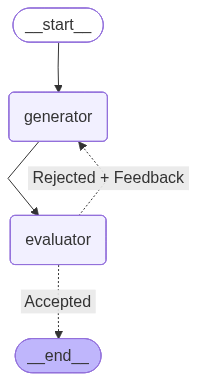

In [5]:
from IPython.display import display, Image

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

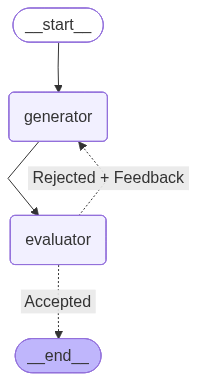

In [6]:
optimizer_workflow

In [7]:
# Invoke
state = optimizer_workflow.invoke({"topic": "고양이"})
print(state["joke"])

[{'type': 'text', 'text': '피드백을 반영하여, 고양이의 실제 습성과 집사들이 공감할 만한 상황을 바탕으로 한 농담 3가지를 준비했습니다.\n\n---\n\n### 1. 고양이의 \'무심함\'에 관하여\n**질문:** 고양이가 세상에서 가장 좋아하는 \'악기\'는 무엇일까요?\n**답변:** \'무시(뮤직)기\'요. \n(고양이를 불러도 쳐다보지도 않고 무시하는 상황에서 착안했습니다.)\n\n---\n\n### 2. 고양이의 \'우다다\' 본능에 관하여\n**질문:** 밤마다 온 집안을 뛰어다니는 고양이를 뭐라고 부르는지 아세요?\n**답변:** \'층간소음 메이커\'요. 이제 윗집에 쿵쿵거리는 소리가 나면 더 이상 사람 탓만 할 수 없겠네요!\n\n---\n\n### 3. 고양이의 \'상자 사랑\'에 관하여\n**질문:** 비싼 캣타워를 사줬더니 굳이 택배 상자 안에만 들어가는 고양이의 심리는 뭘까요?\n**답변:** "이건 내 택배인데, 왜 박스만 가져가고 안에 든 건 너희가 다 가져가냐?"라고 생각하는 중이래요.\n\n---\n\n**[작성 의도 설명]**\n*   **직관성:** 고양이를 키우는 사람이라면 누구나 겪는 \'무시하기\', \'우다다\', \'상자 집착\'이라는 구체적인 행동을 소재로 삼았습니다.\n*   **언어적 유희 개선:** \'묘금\'이나 \'야옹한 과목\'처럼 억지스러운 단어 조작 대신, 고양이의 입장에서 생각하거나 집사의 상황을 대변하는 방식을 택해 자연스러운 피식거림을 유도했습니다.', 'extras': {'signature': 'EjQKMgEMOdbHb2kanwaQV3jovGWJPnZjYI2248eje0bRQcd47IQUS7h635SkKkQ0+G95dQ/k'}}]
